# **SDA Optional Project: Accelerating Convergence in Streaming Time Series with Weight EMA for cGRU**

## **IMPORTS**

In [1]:
import sys
!{sys.executable} -m pip install pandas numpy torch scikit-learn matplotlib scipy tabulate tqdm

from pathlib import Path

# Import necessary libraries
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from sklearn.metrics import cohen_kappa_score
from copy import deepcopy
import matplotlib.pyplot as plt
from scipy.stats import linregress
from tabulate import tabulate

# Library to show a progress bar during the streaming evaluation loop
from tqdm import tqdm

#get parent folder wrt the notebooks folder
PROJECT_ROOT = Path.cwd().parent 
sys.path.append(str(PROJECT_ROOT))
# Import cLSTM and cGRU implementations
from src.models import cLSTM, cGRU
# Import the weight EMA logic
from src.ema import update_ema_weights
#Import data preprocessing
from src.data_preprocessing import StreamingWindowDataset, create_windowed_dataset
#Import metrics
from src.metrics import compute_rolling_kappa, ema_advantage_per_drift, slope_initial_window, convergence_speed_per_drift


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## **LOAD DATASETS**

In [2]:
DATA_PATH = '../data'
weather_ds = pd.read_csv(f'{DATA_PATH}/weather_dataset.csv')
airquality_ds = pd.read_csv(f'{DATA_PATH}/airquality_dataset.csv')

## **HYPERPARAMETERS**

In [3]:
# Number of training epochs
E = 10

# Mini-batch size
B = 128

# Learning rate
LEARNING_RATE = 0.01

# GRU hidden layer size
Hgru = 25

# Window size for Weather dataset
W_weather = 11
# Window size for AirQuality dataset
W_airquality = 10

# Set up loss function for binary classification
criterion = nn.CrossEntropyLoss()

# Print the defined parameters
print("Epochs:", E)
print("Mini-Batch Size:", B)
print("Learning Rate:", LEARNING_RATE)
print("GRU hidden layer size:", Hgru)
print("Window size (Weather dataset):", W_weather)
print("Window size (AirQuality dataset):", W_airquality)

Epochs: 10
Mini-Batch Size: 128
Learning Rate: 0.01
GRU hidden layer size: 25
Window size (Weather dataset): 11
Window size (AirQuality dataset): 10


## **DATASET PREPROCESSING: windows and mini batches**

In [4]:
# Weather dataset feature columns (all except 'task' and 'target')
weather_feature_cols = [c for c in weather_ds.columns if c not in ['task', 'target']]
weather_input_size = len(weather_feature_cols)

# AirQuality dataset feature columns (all except 'task' and 'target')
airquality_feature_cols = [c for c in airquality_ds.columns if c not in ['task', 'target']]
airquality_input_size = len(airquality_feature_cols)

# Build Weather dataset
weather_X, weather_y, weather_tasks = create_windowed_dataset(weather_ds, weather_feature_cols, 'target', 'task', W_weather, 1)
weather_dataset = StreamingWindowDataset(weather_X, weather_y, weather_tasks)

# Build AirQuality Dataset
airquality_X, airquality_y, airquality_tasks = create_windowed_dataset(airquality_ds, airquality_feature_cols, 'target', 'task', W_airquality, 1)
airquality_dataset = StreamingWindowDataset(airquality_X, airquality_y, airquality_tasks)

## **TEST AND TRAIN**: STREAMING EVALUATION LOOP



In [ ]:
# Function for the test-then-train evaluation
# Returns predictions, labels and tasks for the Kappa tracking
# Also return a training loss tracker

def streaming_train_eval(online_model, ema_model, dataset, criterion, optimizer, lam):
    all_preds_online, all_preds_ema, all_labels, all_tasks = [], [], [], []
    total_loss = 0

    batch_losses = [] #new

    loader = DataLoader(dataset, batch_size=B, shuffle=False)

    online_model.train()
    ema_model.eval()

    for X_batch, y_batch, task_batch in tqdm(loader, desc="Batches", leave=False):

        # --- 1. TEST (inference with EMA model) ---
        with torch.no_grad():
            logits_online = online_model(X_batch)
            logits_ema = ema_model(X_batch)

        preds_online = logits_online.argmax(dim=1)
        preds_ema = logits_ema.argmax(dim=1)

        all_preds_online.extend(preds_online.numpy())
        all_preds_ema.extend(preds_ema.numpy())
        all_labels.extend(y_batch.numpy())
        all_tasks.extend(task_batch.numpy())

        # --- 2. TRAIN (update online weights) ---
        batch_loss = 0.0

        for _ in range(E):   # train this mini-batch for E epochs
            optimizer.zero_grad()
            logits_train = online_model(X_batch)
            loss = criterion(logits_train, y_batch)
            loss.backward()
            optimizer.step()

            batch_loss += loss.item()

        #new
        avg_batch_loss = batch_loss / E
        batch_losses.append(avg_batch_loss)

        total_loss += batch_loss / E

        # --- 3. EMA weights update ---
        update_ema_weights(ema_model, online_model, lam)

    return (np.array(all_preds_online), np.array(all_preds_ema), np.array(all_labels), np.array(all_tasks), total_loss/len(loader), np.array(batch_losses))


## **INITIAL TRAINING SETTINGS**
Set λ = 0.7 as a starting baseline — a moderate smoothing value that balances plasticity and stability before exploring the higher λ regimes used in the literature.
The rolling window used to compute Cohen's Kappa is set to B = 128.

In [6]:
# Lambda value for EMA weight update
LAMBDA = 0.7

# Max dimension of the rolling window for the Kappa tracking
# set to the same size of a single mini-batch
K_ROLLING_WINDOW = B

### INSTANTIATE MODELS
One online cGRU model and one EMA cGRU model for each dataset: Weather and AirQuality

In [7]:
# Set seeds for models instantiation (guarantees same initial weights)
torch.manual_seed(42)
np.random.seed(42)

# WEATHER DATASET MODELS
# Instantiate online + EMA cGRU models
gru_online_w = cGRU(input_size=weather_input_size, hidden_dim=Hgru, num_classes=2)
# EMA model starts identical to online, copy everything into new independent memory
gru_ema_w = deepcopy(gru_online_w)

# EMA model never trains in the traditional way, just updates the way with the EMA formula
# Allocating memory for gradients that will never be used is unnecessary
# so put requires_grad to False
for p in gru_ema_w.parameters(): # EMA model never trained directly
    p.requires_grad_(False)

# Set seeds for models instantiation (guarantees same initial weights)
torch.manual_seed(42)
np.random.seed(42)

# AIR QUALITY DATASET MODELS
# Instantiate online + EMA cGRU models
gru_online_aq = cGRU(input_size=airquality_input_size, hidden_dim=Hgru, num_classes=2)
gru_ema_aq = deepcopy(gru_online_aq)
for p in gru_ema_aq.parameters():
    p.requires_grad_(False)

In [8]:
# Define optimizers
gru_optimizer_w = torch.optim.SGD(gru_online_w.parameters(), lr=LEARNING_RATE)
gru_optimizer_aq = torch.optim.SGD(gru_online_aq.parameters(), lr=LEARNING_RATE)

**cGRU EXECUTION - WEATHER DATASET**

In [9]:
all_w_cGRU_preds_online = []
all_w_cGRU_preds_ema    = []
all_w_cGRU_labels       = []
all_w_cGRU_tasks        = []


gru_preds_w, gru_preds_ema_w, gru_labels_w, gru_task_ids_w, gru_avgloss_w, gru_batch_losses_w = streaming_train_eval(
  gru_online_w, gru_ema_w, weather_dataset, criterion, gru_optimizer_w, LAMBDA
)

all_w_cGRU_preds_online.extend(gru_preds_w)
all_w_cGRU_preds_ema.extend(gru_preds_ema_w)
all_w_cGRU_labels.extend(gru_labels_w)
all_w_cGRU_tasks.extend(gru_task_ids_w)

# Compute kappa ONCE over the full accumulated stream
k_w_cGRU_online = compute_rolling_kappa(
    np.array(all_w_cGRU_preds_online),
    np.array(all_w_cGRU_labels),
    np.array(all_w_cGRU_tasks),
    K_ROLLING_WINDOW
)
k_w_cGRU_ema = compute_rolling_kappa(
    np.array(all_w_cGRU_preds_ema),
    np.array(all_w_cGRU_labels),
    np.array(all_w_cGRU_tasks),
    K_ROLLING_WINDOW
)

# Print to notify that the computation finished
print(f"\n cGRU execution and Rolling Cohen's Kappa computation with Weather dataset has finished ")



 cGRU execution and Rolling Cohen's Kappa computation with Weather dataset has finished 


**cGRU EXECUTION - AIRQUALITY DATASET**

In [10]:
all_aq_cGRU_preds_online = []
all_aq_cGRU_preds_ema    = []
all_aq_cGRU_labels       = []
all_aq_cGRU_tasks        = []

gru_preds_aq, gru_preds_ema_aq, gru_labels_aq, gru_task_ids_aq, gru_avgloss_aq, gru_batch_losses_aq = streaming_train_eval(
        gru_online_aq, gru_ema_aq, airquality_dataset, criterion, gru_optimizer_aq, LAMBDA
)

all_aq_cGRU_preds_online.extend(gru_preds_aq)
all_aq_cGRU_preds_ema.extend(gru_preds_ema_aq)
all_aq_cGRU_labels.extend(gru_labels_aq)
all_aq_cGRU_tasks.extend(gru_task_ids_aq)

# Compute kappa ONCE over the full accumulated stream
k_aq_cGRU_online = compute_rolling_kappa(
    np.array(all_aq_cGRU_preds_online),
    np.array(all_aq_cGRU_labels),
    np.array(all_aq_cGRU_tasks),
    K_ROLLING_WINDOW
)
k_aq_cGRU_ema = compute_rolling_kappa(
    np.array(all_aq_cGRU_preds_ema),
    np.array(all_aq_cGRU_labels),
    np.array(all_aq_cGRU_tasks),
    K_ROLLING_WINDOW
)

# Print to notify that the computation finished
print(f"\n cGRU execution and Rolling Cohen's Kappa computation with AirQuality dataset has finished ")


 cGRU execution and Rolling Cohen's Kappa computation with AirQuality dataset has finished 


## **RESULTS**

## PRINT KAPPA PLOTS

In [ ]:
# SANITY CHECKS

# Global accuracy:
# Used only as a diagnostic metric to verify that the model is learning
# non-trivial patterns and is not collapsing to random predictions.
print("Online accuracy:", np.mean(np.array(all_aq_cGRU_preds_online) == np.array(all_aq_cGRU_labels)))
print("EMA accuracy:", np.mean(np.array(all_aq_cGRU_preds_ema) == np.array(all_aq_cGRU_labels)))

# Global Cohen's Kappa: used to check whether the model is learning anything at all
# Used as a compact sanity-check metric to verify whether the model captures predictive signal beyond chance level.
# Kappa -> 0 : predictions close to random/chance agreement
# Kappa > 0 : model learns meaningful signal
# Kappa < 0 : systematic disagreement with labels
print("Online global kappa:", cohen_kappa_score(all_aq_cGRU_labels, all_aq_cGRU_preds_online))
print("EMA global kappa:", cohen_kappa_score(all_aq_cGRU_labels, all_aq_cGRU_preds_ema))

Online accuracy: 0.6141943533356041
EMA accuracy: 0.6115574062238075
Online global kappa: 0.22759596138836058
EMA global kappa: 0.2222887038499991


In [12]:
def plot_kappa(k_online, k_ema, tasks, title):
    plt.figure(figsize=(14, 4))

    # Plot kappa curves
    plt.plot(k_online, label='cGRU online', alpha=0.8)
    plt.plot(k_ema,    label='cGRU EMA',    alpha=0.8)

    # Mark concept drift positions with vertical lines
    drift_points = [i for i in range(1, len(tasks)) if tasks[i] != tasks[i-1]]
    for d in drift_points:
        plt.axvline(x=d, color='red', linestyle='--', alpha=0.5, label='concept drift' if d == drift_points[0] else '')

    plt.xlabel('Streaming prediction steps')
    plt.ylabel('Rolling Cohen\'s Kappa')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

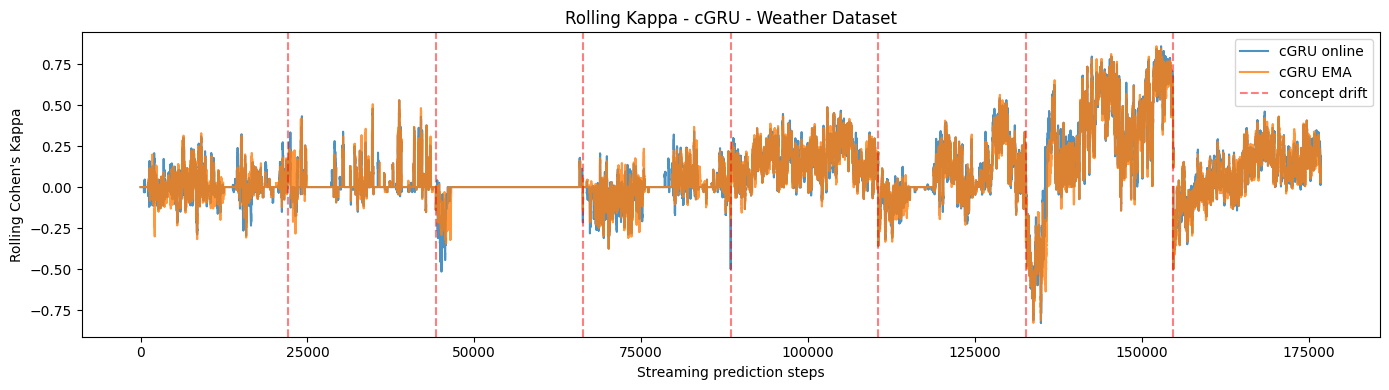

In [13]:
# Weather cGRU
plot_kappa(
    k_w_cGRU_online,
    k_w_cGRU_ema,
    np.array(all_w_cGRU_tasks),
    'Rolling Kappa - cGRU - Weather Dataset'
)

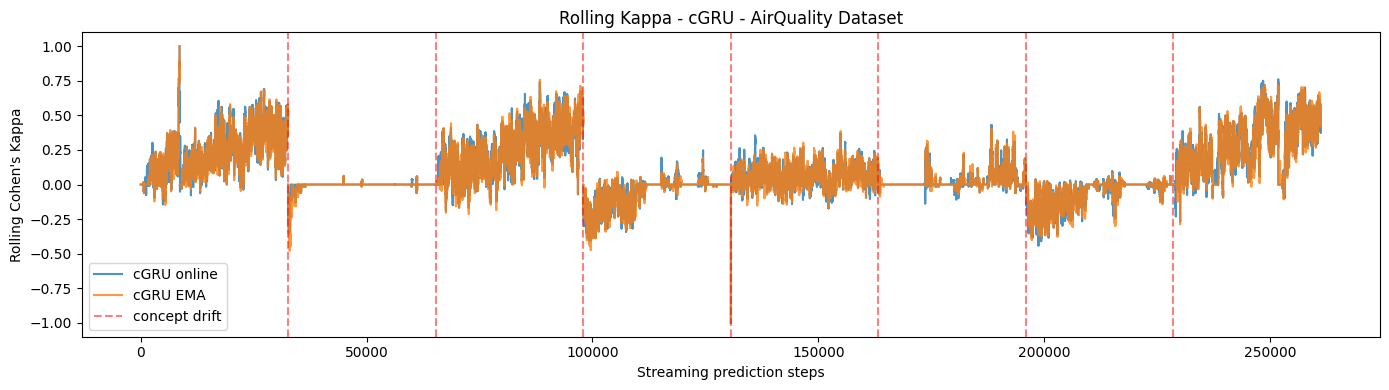

In [14]:
# AirQuality cGRU
plot_kappa(
    k_aq_cGRU_online,
    k_aq_cGRU_ema,
    np.array(all_aq_cGRU_tasks),
    'Rolling Kappa - cGRU - AirQuality Dataset'
)

## POST-DRIFT ANALYSIS

This section introduces quantitative metrics to analyze post-drift adaptation behavior using the Rolling Cohen’s Kappa curves.

The analysis separates visualization from quantitative convergence measurement:

- **Drift distance analysis**: used to determine a valid `ZOOM_WINDOW` that remains entirely within a single post-drift adaptation phase and does not overlap with the next concept drift. This window is used only for plots, not for quantitative metrics.

- **Post-drift zoom plots**: show the Rolling Kappa curves immediately after each concept drift, allowing visual comparison between online and EMA models.

- **EMA advantage per drift**: computes the average Rolling Kappa gap (EMA − online) over the first SLOPE_WINDOW samples following each drift. Positive values indicate better short-term post-drift performance for EMA.

- **Relative threshold estimation**: for each drift, both models are evaluated against the same target equal to 90% of the higher of their two within-concept maximum kappa values. This relative threshold adapts to concept difficulty: easy concepts where kappa rises high produce a high target, harder concepts produce a low target. Both models are measured against the same bar to ensure fair comparison.

- **Convergence speed per drift**: measures:
  - the Time-To-Threshold (TTP), the first sample after the drift where rolling kappa reaches the relative target;
  - Slope: regression slope of the kappa curve over a fixed SLOPE_WINDOW immediately after the drift, capturing post-drift responsiveness independent of how long recovery takes.

- **Summary statistics**: aggregate results are printed for each dataset to compare:
  - online vs EMA behavior,
  - convergence speed,
  - and recovery quality.

## **ZOOM IN PLOT AFTER EACH DRIFT**

### **DRIFT DISTANCE CHECK**

To zoom in on the moments immediately following concept drifts and compare recovery curves, the selected window must not overlap with the next concept drift.

The visualization window ZOOM_WINDOW is set to 80% of the shortest inter-drift distance, ensuring it stays within one concept. The quantitative slope analysis uses a separate, smaller window SLOPE_WINDOW = 3 × B = 384, capturing the immediate post-drift response phase. Using different windows for visualization and metrics keeps each parameter aligned with its purpose: ZOOM_WINDOW is for human readability, SLOPE_WINDOW for comparable slope magnitudes across drifts.

In [15]:
def check_drift_distances(tasks, name):
    drift_points = [i for i in range(1, len(tasks)) if tasks[i] != tasks[i-1]]
    distances = [drift_points[i+1] - drift_points[i] for i in range(len(drift_points)-1)]
    print(f"\n{name}")
    print(f"  Min distance between drifts: {min(distances)}")

    #non ci servono questi, li possiamo togliere penso
    print(f"  Max distance between drifts: {max(distances)}")
    print(f"  Mean distance between drifts: {np.nanmean(distances):.1f}")

    return min(distances)

In [16]:
# Check drift distance to set zoom_window
min_dist_weather = check_drift_distances(np.array(all_w_cGRU_tasks), "Weather")
min_dist_airquality = check_drift_distances(np.array(all_aq_cGRU_tasks), "AirQuality")

ZOOM_WINDOW = int(min(min_dist_weather, min_dist_airquality) * 0.8)
print(f"\nZoom window: {ZOOM_WINDOW}")
SLOPE_WINDOW = int(min(3*B, ZOOM_WINDOW * 0.8))# 384 samples — "immediately after" the drift
print(f"\nSlope window set to: {SLOPE_WINDOW}")


Weather
  Min distance between drifts: 22105
  Max distance between drifts: 22108
  Mean distance between drifts: 22106.8

AirQuality
  Min distance between drifts: 32663
  Max distance between drifts: 32664
  Mean distance between drifts: 32663.2

Zoom window: 17684

Slope window set to: 384


In [17]:
def plot_kappa_zoom(k_online, k_ema, tasks, title, zoom_window=200):
    drift_points = [i for i in range(1, len(tasks)) if tasks[i] != tasks[i-1]]

    n_drifts = len(drift_points)
    fig, axes = plt.subplots(1, n_drifts, figsize=(5 * n_drifts, 4))
    if n_drifts == 1:
        axes = [axes]

    for ax, d in zip(axes, drift_points):
        start = d
        end   = min(d + zoom_window, len(k_online))

        ax.plot(k_online[start:end], label='online', alpha=0.8)
        ax.plot(k_ema[start:end],    label='EMA',    alpha=0.8)
        ax.axvline(x=0, color='red', linestyle='--', label='drift')
        ax.set_title(f'Drift at sample {d}')
        ax.set_xlabel('Samples after drift')
        ax.set_ylabel('Rolling Kappa')
        ax.legend()

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

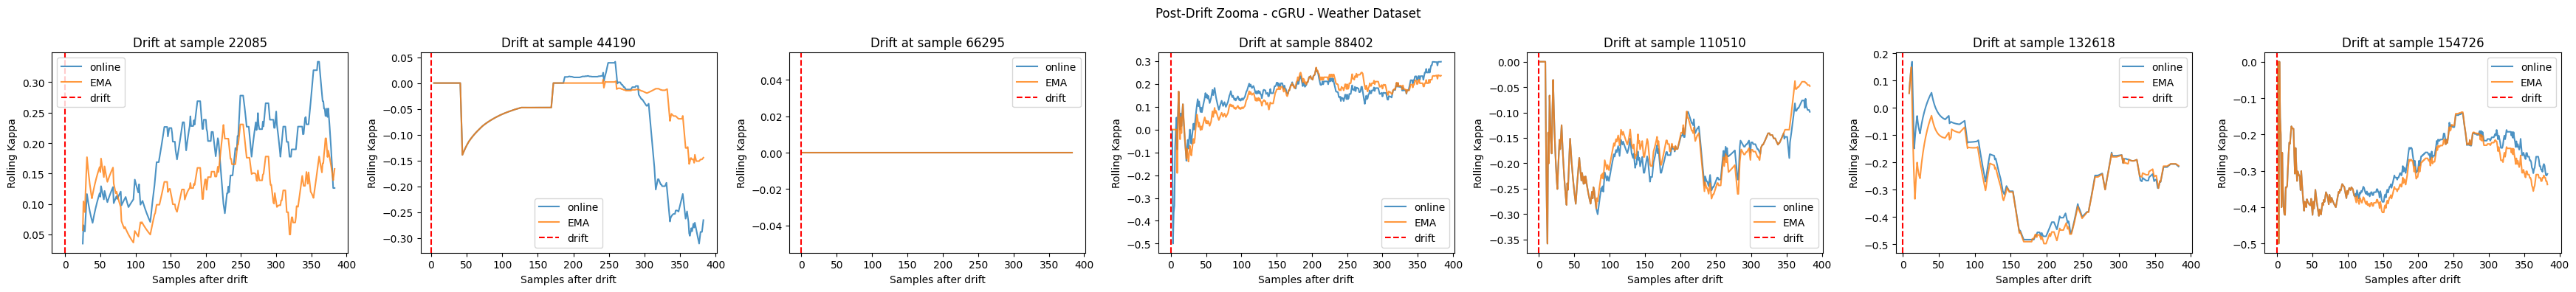

In [18]:
# Weather cGRU
plot_kappa_zoom(
    k_w_cGRU_online,
    k_w_cGRU_ema,
    np.array(all_w_cGRU_tasks),
    'Post-Drift Zooma - cGRU - Weather Dataset',
    SLOPE_WINDOW
)

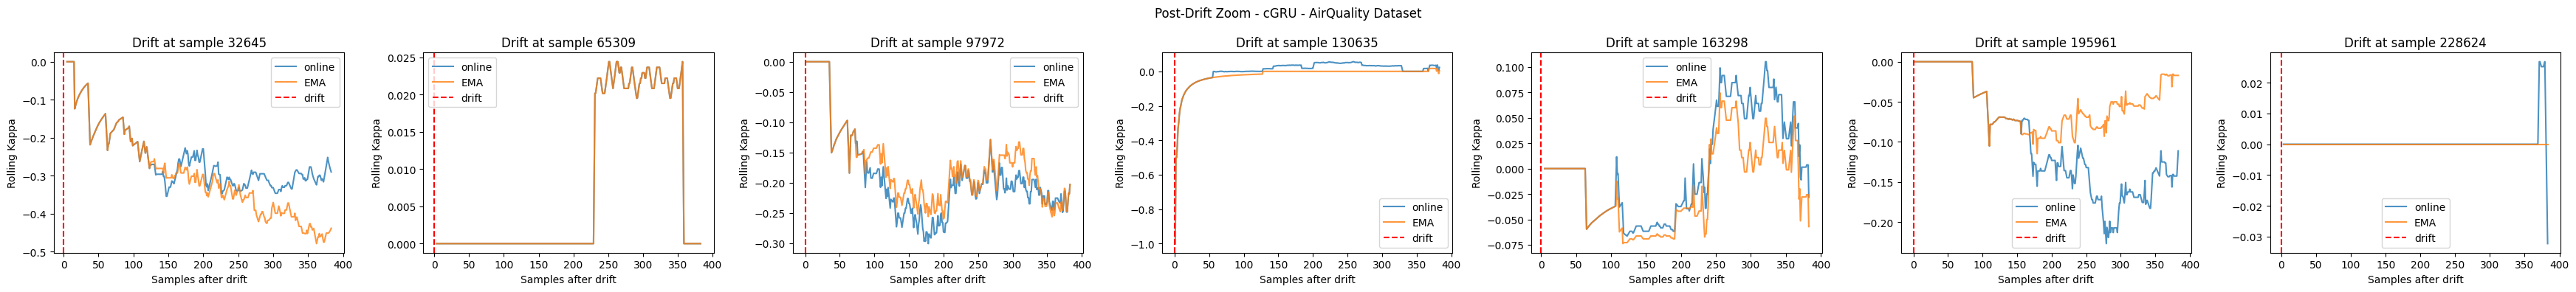

In [19]:
# AirQuality cGRU
plot_kappa_zoom(
    k_aq_cGRU_online,
    k_aq_cGRU_ema,
    np.array(all_aq_cGRU_tasks),
    'Post-Drift Zoom - cGRU - AirQuality Dataset',
    SLOPE_WINDOW
)

In [20]:
#ATTENZIONE
#Just remember: TTP mean only includes drifts where both models reached threshold,
#while ttp_wins also counts cases where EMA reached and online did not. That is okay, but mention it if needed.

def print_convergence_summary(results, name):
    slope_wins = sum(r['slope_ema_wins'] for r in results)
    ttp_wins   = sum(r['ttp_ema_wins']   for r in results)
    total      = len(results)

    mean_slope_online = np.nanmean([r['slope_online'] for r in results])
    mean_slope_ema    = np.nanmean([r['slope_ema']    for r in results])

    # Only include drifts where both models reached the threshold
    ttp_pairs = [(r['ttp_online'], r['ttp_ema']) for r in results
                  if r['ttp_online'] is not None and r['ttp_ema'] is not None]
    mean_ttp_online   = np.nanmean([p[0] for p in ttp_pairs])   if ttp_pairs else float('nan')
    mean_ttp_ema      = np.nanmean([p[1] for p in ttp_pairs])   if ttp_pairs else float('nan')
    median_ttp_online = np.nanmedian([p[0] for p in ttp_pairs]) if ttp_pairs else float('nan')
    median_ttp_ema    = np.nanmedian([p[1] for p in ttp_pairs]) if ttp_pairs else float('nan')

    print(f"\n{name}")
    print(f"  Slope  — EMA wins {slope_wins}/{total} drifts | "
          f"Mean slope online: {mean_slope_online:+.5f} | EMA: {mean_slope_ema:+.5f}")
    print(f"  TTP    — EMA wins {ttp_wins}/{total} drifts | "
          f"Mean TTP online: {mean_ttp_online:.1f} | EMA: {mean_ttp_ema:.1f} | "
          f"Median TTP online: {median_ttp_online:.1f} | EMA: {median_ttp_ema:.1f}")

In [21]:
# Print summary
def print_summary(results, name):
    wins = sum(r['ema_wins'] for r in results)
    total = len(results)
    avg = np.nanmean([r['avg_gap'] for r in results])
    print(f"{name}: EMA wins {wins}/{total} drifts | Mean gap: {avg:+.4f}")

In [23]:
# Weather
w_gru_adv = ema_advantage_per_drift(k_w_cGRU_online, k_w_cGRU_ema, np.array(all_w_cGRU_tasks), SLOPE_WINDOW)
w_gru_conv = convergence_speed_per_drift(k_w_cGRU_online, k_w_cGRU_ema, np.array(all_w_cGRU_tasks), SLOPE_WINDOW)

# AirQuality
aq_gru_adv = ema_advantage_per_drift(k_aq_cGRU_online, k_aq_cGRU_ema, np.array(all_aq_cGRU_tasks), SLOPE_WINDOW)
aq_gru_conv = convergence_speed_per_drift(k_aq_cGRU_online, k_aq_cGRU_ema, np.array(all_aq_cGRU_tasks), SLOPE_WINDOW)


In [24]:
# --- Print all results ---
print("SHORT-TERM POST-DRIFT ADVANTAGE (kappa gap) IN SLOPE WINDOW")
print_summary(w_gru_adv, "cGRU - Weather")
print_summary(aq_gru_adv, "cGRU - AirQuality")

print("\nCONVERGENCE SPEED (slope + time-to-threshold)")
print_convergence_summary(w_gru_conv, "cGRU - Weather")
print_convergence_summary(aq_gru_conv, "cGRU - AirQuality")

# Final rolling kappa values at the end of the stream
print("Final rolling kappa")
print(f"cGRU Weather   - online: {k_w_cGRU_online[-1]:.4f}  | EMA: {k_w_cGRU_ema[-1]:.4f}")
print(f"cGRU AirQuality - online: {k_aq_cGRU_online[-1]:.4f} | EMA: {k_aq_cGRU_ema[-1]:.4f}")

# Mean rolling kappa over the entire stream
print("\nMean rolling kappa over the stream")
print(f"cGRU Weather - online: {np.nanmean(k_w_cGRU_online):.4f}  | EMA: {np.nanmean(k_w_cGRU_ema):.4f}")
print(f"cGRU AirQuality - online: {np.nanmean(k_aq_cGRU_online):.4f} | EMA: {np.nanmean(k_aq_cGRU_ema):.4f}")

SHORT-TERM POST-DRIFT ADVANTAGE (kappa gap) IN SLOPE WINDOW
cGRU - Weather: EMA wins 2/7 drifts | Mean gap: -0.0104
cGRU - AirQuality: EMA wins 2/7 drifts | Mean gap: -0.0025

CONVERGENCE SPEED (slope + time-to-threshold)

cGRU - Weather
  Slope  — EMA wins 3/7 drifts | Mean slope online: +0.00007 | EMA: +0.00012
  TTP    — EMA wins 3/7 drifts | Mean TTP online: 13148.3 | EMA: 14252.3 | Median TTP online: 13185.5 | EMA: 14063.5

cGRU - AirQuality
  Slope  — EMA wins 2/7 drifts | Mean slope online: -0.00011 | EMA: -0.00014
  TTP    — EMA wins 1/7 drifts | Mean TTP online: 17051.6 | EMA: 20833.4 | Median TTP online: 19505.0 | EMA: 23033.0
Final rolling kappa
cGRU Weather   - online: 0.1713  | EMA: 0.0875
cGRU AirQuality - online: 0.4880 | EMA: 0.4538

Mean rolling kappa over the stream
cGRU Weather - online: 0.0794  | EMA: 0.0753
cGRU AirQuality - online: 0.0923 | EMA: 0.0881


# **λ TUNING EXPERIMENTS**
## **EXPERIMENT 1 - λ = 0.8**

The λ value in the EMA weight averaging formula is not fixed by the project requirements and is therefore tuned empirically. We start from λ = 0.7 as a moderate baseline (Experiment 0) and increase the smoothing strength up to λ = 0.99, the value used by Soutif-Cormerais et al. (2023), to characterize the full range from weak to strong smoothing in the streaming RNN setting.



In [25]:
#New lambda values
LAMBDA_TUNE1 = 0.8

## INSTANTIATE MODELS

In [26]:
# Reinitialize all models with fresh random weights for the lambda tuning experiment
# This ensures a clean and fair comparison independent of the previous λ=0.7 experiment
# Set seeds for models instantiation (guarantees same initial weights)
torch.manual_seed(42)
np.random.seed(42)

# Weather cGRU
gru_online_w_tune = cGRU(input_size=weather_input_size, hidden_dim=Hgru, num_classes=2)
gru_ema_w_tune = deepcopy(gru_online_w_tune)
for p in gru_ema_w_tune.parameters(): p.requires_grad_(False)

# Set seeds for models instantiation (guarantees same initial weights)
torch.manual_seed(42)
np.random.seed(42)

# AirQuality cGRU
gru_online_aq_tune = cGRU(input_size=airquality_input_size, hidden_dim=Hgru, num_classes=2)
gru_ema_aq_tune = deepcopy(gru_online_aq_tune)
for p in gru_ema_aq_tune.parameters(): p.requires_grad_(False)

# Optimizers
gru_optimizer_w_tune = torch.optim.SGD(gru_online_w_tune.parameters(), lr=LEARNING_RATE)
gru_optimizer_aq_tune = torch.optim.SGD(gru_online_aq_tune.parameters(), lr=LEARNING_RATE)

**cGRU EXECUTION - WEATHER DATASET**

In [27]:
all_w_cGRU_preds_online_tune = []
all_w_cGRU_preds_ema_tune    = []
all_w_cGRU_labels_tune       = []
all_w_cGRU_tasks_tune        = []


gru_preds_w, gru_preds_ema_w, gru_labels_w, gru_task_ids_w, gru_avgloss_w, gru_batch_losses_w = streaming_train_eval(
    gru_online_w_tune, gru_ema_w_tune, weather_dataset, criterion, gru_optimizer_w_tune, LAMBDA_TUNE1
)

all_w_cGRU_preds_online_tune.extend(gru_preds_w)
all_w_cGRU_preds_ema_tune.extend(gru_preds_ema_w)
all_w_cGRU_labels_tune.extend(gru_labels_w)
all_w_cGRU_tasks_tune.extend(gru_task_ids_w)

k_w_cGRU_online_tune = compute_rolling_kappa(
    np.array(all_w_cGRU_preds_online_tune),
    np.array(all_w_cGRU_labels_tune),
    np.array(all_w_cGRU_tasks_tune),
    K_ROLLING_WINDOW
)
k_w_cGRU_ema_tune = compute_rolling_kappa(
    np.array(all_w_cGRU_preds_ema_tune),
    np.array(all_w_cGRU_labels_tune),
    np.array(all_w_cGRU_tasks_tune),
    K_ROLLING_WINDOW
)

print(f"\n cGRU | Weather | λ=0.8 finished")


 cGRU | Weather | λ=0.8 finished


**cGRU EXECUTION - AIR QUALITY DATASET**

In [28]:
all_aq_cGRU_preds_online_tune = []
all_aq_cGRU_preds_ema_tune    = []
all_aq_cGRU_labels_tune       = []
all_aq_cGRU_tasks_tune        = []


gru_preds_aq, gru_preds_ema_aq, gru_labels_aq, gru_task_ids_aq, gru_avgloss_aq, gru_batch_losses_aq = streaming_train_eval(
        gru_online_aq_tune, gru_ema_aq_tune, airquality_dataset, criterion, gru_optimizer_aq_tune, LAMBDA_TUNE1
)

all_aq_cGRU_preds_online_tune.extend(gru_preds_aq)
all_aq_cGRU_preds_ema_tune.extend(gru_preds_ema_aq)
all_aq_cGRU_labels_tune.extend(gru_labels_aq)
all_aq_cGRU_tasks_tune.extend(gru_task_ids_aq)

k_aq_cGRU_online_tune = compute_rolling_kappa(
    np.array(all_aq_cGRU_preds_online_tune),
    np.array(all_aq_cGRU_labels_tune),
    np.array(all_aq_cGRU_tasks_tune),
    K_ROLLING_WINDOW
)
k_aq_cGRU_ema_tune = compute_rolling_kappa(
    np.array(all_aq_cGRU_preds_ema_tune),
    np.array(all_aq_cGRU_labels_tune),
    np.array(all_aq_cGRU_tasks_tune),
    K_ROLLING_WINDOW
)

print(f"\n cGRU | AirQuality | λ=0.8 finished")

Batches:   0%|          | 0/2042 [00:00<?, ?it/s]


 cGRU | AirQuality | λ=0.8 finished


In [29]:
# Weather (tuned λ)
w_gru_adv_tune = ema_advantage_per_drift(k_w_cGRU_online_tune, k_w_cGRU_ema_tune, np.array(all_w_cGRU_tasks_tune), SLOPE_WINDOW)
w_gru_conv_tune = convergence_speed_per_drift(k_w_cGRU_online_tune, k_w_cGRU_ema_tune, np.array(all_w_cGRU_tasks_tune), SLOPE_WINDOW)

# AirQuality (tuned λ)
aq_gru_adv_tune = ema_advantage_per_drift(k_aq_cGRU_online_tune, k_aq_cGRU_ema_tune, np.array(all_aq_cGRU_tasks_tune), SLOPE_WINDOW)
aq_gru_conv_tune = convergence_speed_per_drift(k_aq_cGRU_online_tune, k_aq_cGRU_ema_tune, np.array(all_aq_cGRU_tasks_tune), SLOPE_WINDOW)

## **λ TUNING EXPERIMENT 2 - λ = 0.9**
**Summary so far**

Results from λ = 0.7 (baseline) and λ = 0.8 (Experiment 1) are now available for both datasets. The next experiments increase λ further to map the full smoothing-vs-plasticity tradeoff.

In [30]:
#New lambda values
LAMBDA_TUNE2 = 0.9

In [31]:
# Reinitialize all models with fresh random weights for the lambda tuning experiment
# This ensures a clean and fair comparison independent of the previous λ=0.7 experiment
# Set seeds for models instantiation (guarantees same initial weights)
torch.manual_seed(42)
np.random.seed(42)

# Weather cGRU
gru_online_w_tune2 = cGRU(input_size=weather_input_size, hidden_dim=Hgru, num_classes=2)
gru_ema_w_tune2 = deepcopy(gru_online_w_tune2)
for p in gru_ema_w_tune2.parameters(): p.requires_grad_(False)

# Set seeds for models instantiation (guarantees same initial weights)
torch.manual_seed(42)
np.random.seed(42)

# AirQuality cGRU
gru_online_aq_tune2 = cGRU(input_size=airquality_input_size, hidden_dim=Hgru, num_classes=2)
gru_ema_aq_tune2 = deepcopy(gru_online_aq_tune2)
for p in gru_ema_aq_tune2.parameters(): p.requires_grad_(False)

# Optimizers
gru_optimizer_w_tune2 = torch.optim.SGD(gru_online_w_tune2.parameters(), lr=LEARNING_RATE)
gru_optimizer_aq_tune2 = torch.optim.SGD(gru_online_aq_tune2.parameters(), lr=LEARNING_RATE)


### **cGRU - WEATHER DATASET**

In [32]:
all_w_cGRU_preds_online_tune2 = []
all_w_cGRU_preds_ema_tune2    = []
all_w_cGRU_labels_tune2       = []
all_w_cGRU_tasks_tune2        = []


gru_preds_w, gru_preds_ema_w, gru_labels_w, gru_task_ids_w, gru_avgloss_w, gru_batch_losses_w = streaming_train_eval(
      gru_online_w_tune2, gru_ema_w_tune2, weather_dataset, criterion, gru_optimizer_w_tune2, LAMBDA_TUNE2
)

all_w_cGRU_preds_online_tune2.extend(gru_preds_w)
all_w_cGRU_preds_ema_tune2.extend(gru_preds_ema_w)
all_w_cGRU_labels_tune2.extend(gru_labels_w)
all_w_cGRU_tasks_tune2.extend(gru_task_ids_w)

k_w_cGRU_online_tune2 = compute_rolling_kappa(
    np.array(all_w_cGRU_preds_online_tune2),
    np.array(all_w_cGRU_labels_tune2),
    np.array(all_w_cGRU_tasks_tune2),
    K_ROLLING_WINDOW
)
k_w_cGRU_ema_tune2 = compute_rolling_kappa(
    np.array(all_w_cGRU_preds_ema_tune2),
    np.array(all_w_cGRU_labels_tune2),
    np.array(all_w_cGRU_tasks_tune2),
    K_ROLLING_WINDOW
)

print(f"\n cGRU | Weather | λ=0.9 finished")


 cGRU | Weather | λ=0.9 finished


### **cGRU - AIRQUALITY DATASET**

In [33]:
all_aq_cGRU_preds_online_tune2 = []
all_aq_cGRU_preds_ema_tune2    = []
all_aq_cGRU_labels_tune2       = []
all_aq_cGRU_tasks_tune2        = []

gru_preds_aq, gru_preds_ema_aq, gru_labels_aq, gru_task_ids_aq, gru_avgloss_aq, gru_batch_losses_aq = streaming_train_eval(
    gru_online_aq_tune2, gru_ema_aq_tune2, airquality_dataset, criterion, gru_optimizer_aq_tune2, LAMBDA_TUNE2
)

all_aq_cGRU_preds_online_tune2.extend(gru_preds_aq)
all_aq_cGRU_preds_ema_tune2.extend(gru_preds_ema_aq)
all_aq_cGRU_labels_tune2.extend(gru_labels_aq)
all_aq_cGRU_tasks_tune2.extend(gru_task_ids_aq)

k_aq_cGRU_online_tune2 = compute_rolling_kappa(
    np.array(all_aq_cGRU_preds_online_tune2),
    np.array(all_aq_cGRU_labels_tune2),
    np.array(all_aq_cGRU_tasks_tune2),
    K_ROLLING_WINDOW
)
k_aq_cGRU_ema_tune2 = compute_rolling_kappa(
    np.array(all_aq_cGRU_preds_ema_tune2),
    np.array(all_aq_cGRU_labels_tune2),
    np.array(all_aq_cGRU_tasks_tune2),
    K_ROLLING_WINDOW
)

print(f"\n cGRU | AirQuality | λ=0.9 finished")


 cGRU | AirQuality | λ=0.9 finished


In [34]:
# Compute for all 4 combinations - Weather (tuned λ)
w_gru_adv_tune2 = ema_advantage_per_drift(k_w_cGRU_online_tune2, k_w_cGRU_ema_tune2, np.array(all_w_cGRU_tasks_tune2), SLOPE_WINDOW)
w_gru_conv_tune2 = convergence_speed_per_drift(k_w_cGRU_online_tune2, k_w_cGRU_ema_tune2, np.array(all_w_cGRU_tasks_tune2), SLOPE_WINDOW)

# AirQuality (tuned λ)
aq_gru_adv_tune2 = ema_advantage_per_drift(k_aq_cGRU_online_tune2, k_aq_cGRU_ema_tune2, np.array(all_aq_cGRU_tasks_tune2), SLOPE_WINDOW)
aq_gru_conv_tune2 = convergence_speed_per_drift(k_aq_cGRU_online_tune2, k_aq_cGRU_ema_tune2, np.array(all_aq_cGRU_tasks_tune2), SLOPE_WINDOW)

## **λ TUNING EXPERIMENT 3 - λ = 0.95**

In [35]:
#New lambda values
LAMBDA_TUNE3 = 0.95

In [36]:
# Reinitialize all models with fresh random weights for the lambda tuning experiment
# This ensures a clean and fair comparison independent of the previous λ=0.7 experiment

# Set seeds for models instantiation (guarantees same initial weights)
torch.manual_seed(42)
np.random.seed(42)

# Weather cGRU
gru_online_w_tune3 = cGRU(input_size=weather_input_size, hidden_dim=Hgru, num_classes=2)
gru_ema_w_tune3 = deepcopy(gru_online_w_tune3)
for p in gru_ema_w_tune3.parameters(): p.requires_grad_(False)

# Set seeds for models instantiation (guarantees same initial weights)
torch.manual_seed(42)
np.random.seed(42)

# AirQuality cGRU
gru_online_aq_tune3 = cGRU(input_size=airquality_input_size, hidden_dim=Hgru, num_classes=2)
gru_ema_aq_tune3 = deepcopy(gru_online_aq_tune3)
for p in gru_ema_aq_tune3.parameters(): p.requires_grad_(False)

# Optimizers
gru_optimizer_w_tune3 = torch.optim.SGD(gru_online_w_tune3.parameters(), lr=LEARNING_RATE)
gru_optimizer_aq_tune3 = torch.optim.SGD(gru_online_aq_tune3.parameters(), lr=LEARNING_RATE)


**cGRU EXECUTION - WEATHER DATASET**

In [37]:
all_w_cGRU_preds_online_tune3 = []
all_w_cGRU_preds_ema_tune3    = []
all_w_cGRU_labels_tune3       = []
all_w_cGRU_tasks_tune3        = []

gru_preds_w, gru_preds_ema_w, gru_labels_w, gru_task_ids_w, gru_avgloss_w, gru_batch_losses_w = streaming_train_eval(
      gru_online_w_tune3, gru_ema_w_tune3, weather_dataset, criterion, gru_optimizer_w_tune3, LAMBDA_TUNE3
)

all_w_cGRU_preds_online_tune3.extend(gru_preds_w)
all_w_cGRU_preds_ema_tune3.extend(gru_preds_ema_w)
all_w_cGRU_labels_tune3.extend(gru_labels_w)
all_w_cGRU_tasks_tune3.extend(gru_task_ids_w)

k_w_cGRU_online_tune3 = compute_rolling_kappa(
    np.array(all_w_cGRU_preds_online_tune3),
    np.array(all_w_cGRU_labels_tune3),
    np.array(all_w_cGRU_tasks_tune3),
    K_ROLLING_WINDOW
)
k_w_cGRU_ema_tune3 = compute_rolling_kappa(
    np.array(all_w_cGRU_preds_ema_tune3),
    np.array(all_w_cGRU_labels_tune3),
    np.array(all_w_cGRU_tasks_tune3),
    K_ROLLING_WINDOW
)

print(f"\n cGRU | Weather | λ=0.95 finished")


 cGRU | Weather | λ=0.95 finished


**cGRU EXECUTION - AIRQUALITY DATASET**

In [38]:
all_aq_cGRU_preds_online_tune3 = []
all_aq_cGRU_preds_ema_tune3    = []
all_aq_cGRU_labels_tune3       = []
all_aq_cGRU_tasks_tune3        = []

gru_preds_aq, gru_preds_ema_aq, gru_labels_aq, gru_task_ids_aq, gru_avgloss_aq, gru_batch_losses_aq = streaming_train_eval(
    gru_online_aq_tune3, gru_ema_aq_tune3, airquality_dataset, criterion, gru_optimizer_aq_tune3, LAMBDA_TUNE3
)

all_aq_cGRU_preds_online_tune3.extend(gru_preds_aq)
all_aq_cGRU_preds_ema_tune3.extend(gru_preds_ema_aq)
all_aq_cGRU_labels_tune3.extend(gru_labels_aq)
all_aq_cGRU_tasks_tune3.extend(gru_task_ids_aq)

k_aq_cGRU_online_tune3 = compute_rolling_kappa(
    np.array(all_aq_cGRU_preds_online_tune3),
    np.array(all_aq_cGRU_labels_tune3),
    np.array(all_aq_cGRU_tasks_tune3),
    K_ROLLING_WINDOW
)
k_aq_cGRU_ema_tune3 = compute_rolling_kappa(
    np.array(all_aq_cGRU_preds_ema_tune3),
    np.array(all_aq_cGRU_labels_tune3),
    np.array(all_aq_cGRU_tasks_tune3),
    K_ROLLING_WINDOW
)

print(f"\n cGRU | AirQuality | λ=0.95 finished")


 cGRU | AirQuality | λ=0.95 finished


In [39]:
# Weather (tuned λ)
w_gru_adv_tune3 = ema_advantage_per_drift(k_w_cGRU_online_tune3, k_w_cGRU_ema_tune3, np.array(all_w_cGRU_tasks_tune3), SLOPE_WINDOW)
w_gru_conv_tune3 = convergence_speed_per_drift(k_w_cGRU_online_tune3, k_w_cGRU_ema_tune3, np.array(all_w_cGRU_tasks_tune3), SLOPE_WINDOW)

# AirQuality (tuned λ)
aq_gru_adv_tune3 = ema_advantage_per_drift(k_aq_cGRU_online_tune3, k_aq_cGRU_ema_tune3, np.array(all_aq_cGRU_tasks_tune3), SLOPE_WINDOW)
aq_gru_conv_tune3 = convergence_speed_per_drift(k_aq_cGRU_online_tune3, k_aq_cGRU_ema_tune3, np.array(all_aq_cGRU_tasks_tune3), SLOPE_WINDOW)

## **λ TUNING EXPERIMENT 4 - λ = 0.99**

In [40]:
#New lambda values
LAMBDA_TUNE4 = 0.99

In [41]:
# Reinitialize all models with fresh random weights for the lambda tuning experiment
# This ensures a clean and fair comparison independent of the previous λ=0.7 experiment
# Set seeds for models instantiation (guarantees same initial weights)
torch.manual_seed(42)
np.random.seed(42)

# Weather cGRU
gru_online_w_tune4 = cGRU(input_size=weather_input_size, hidden_dim=Hgru, num_classes=2)
gru_ema_w_tune4 = deepcopy(gru_online_w_tune4)
for p in gru_ema_w_tune4.parameters(): p.requires_grad_(False)

# Set seeds for models instantiation (guarantees same initial weights)
torch.manual_seed(42)
np.random.seed(42)

# AirQuality cGRU
gru_online_aq_tune4 = cGRU(input_size=airquality_input_size, hidden_dim=Hgru, num_classes=2)
gru_ema_aq_tune4 = deepcopy(gru_online_aq_tune4)
for p in gru_ema_aq_tune4.parameters(): p.requires_grad_(False)

# Optimizers
gru_optimizer_w_tune4 = torch.optim.SGD(gru_online_w_tune4.parameters(), lr=LEARNING_RATE)
gru_optimizer_aq_tune4 = torch.optim.SGD(gru_online_aq_tune4.parameters(), lr=LEARNING_RATE)


In [42]:
all_w_cGRU_preds_online_tune4 = []
all_w_cGRU_preds_ema_tune4    = []
all_w_cGRU_labels_tune4       = []
all_w_cGRU_tasks_tune4        = []

gru_preds_w, gru_preds_ema_w, gru_labels_w, gru_task_ids_w, gru_avgloss_w, gru_batch_losses_w = streaming_train_eval(
      gru_online_w_tune4, gru_ema_w_tune4, weather_dataset, criterion, gru_optimizer_w_tune4, LAMBDA_TUNE4
)

all_w_cGRU_preds_online_tune4.extend(gru_preds_w)
all_w_cGRU_preds_ema_tune4.extend(gru_preds_ema_w)
all_w_cGRU_labels_tune4.extend(gru_labels_w)
all_w_cGRU_tasks_tune4.extend(gru_task_ids_w)

k_w_cGRU_online_tune4 = compute_rolling_kappa(
    np.array(all_w_cGRU_preds_online_tune4),
    np.array(all_w_cGRU_labels_tune4),
    np.array(all_w_cGRU_tasks_tune4),
    K_ROLLING_WINDOW
)
k_w_cGRU_ema_tune4 = compute_rolling_kappa(
    np.array(all_w_cGRU_preds_ema_tune4),
    np.array(all_w_cGRU_labels_tune4),
    np.array(all_w_cGRU_tasks_tune4),
    K_ROLLING_WINDOW
)

print(f"\n cGRU | Weather | λ=0.99 finished")


 cGRU | Weather | λ=0.99 finished


In [43]:
all_aq_cGRU_preds_online_tune4 = []
all_aq_cGRU_preds_ema_tune4    = []
all_aq_cGRU_labels_tune4       = []
all_aq_cGRU_tasks_tune4        = []

gru_preds_aq, gru_preds_ema_aq, gru_labels_aq, gru_task_ids_aq, gru_avgloss_aq, gru_batch_losses_aq = streaming_train_eval(
    gru_online_aq_tune4, gru_ema_aq_tune4, airquality_dataset, criterion, gru_optimizer_aq_tune4, LAMBDA_TUNE4
)

all_aq_cGRU_preds_online_tune4.extend(gru_preds_aq)
all_aq_cGRU_preds_ema_tune4.extend(gru_preds_ema_aq)
all_aq_cGRU_labels_tune4.extend(gru_labels_aq)
all_aq_cGRU_tasks_tune4.extend(gru_task_ids_aq)

k_aq_cGRU_online_tune4 = compute_rolling_kappa(
    np.array(all_aq_cGRU_preds_online_tune4),
    np.array(all_aq_cGRU_labels_tune4),
    np.array(all_aq_cGRU_tasks_tune4),
    K_ROLLING_WINDOW
)
k_aq_cGRU_ema_tune4 = compute_rolling_kappa(
    np.array(all_aq_cGRU_preds_ema_tune4),
    np.array(all_aq_cGRU_labels_tune4),
    np.array(all_aq_cGRU_tasks_tune4),
    K_ROLLING_WINDOW
)

print(f"\n cGRU | AirQuality | λ=0.99 finished")


 cGRU | AirQuality | λ=0.99 finished


In [44]:
# Weather (tuned λ)
w_gru_adv_tune4 = ema_advantage_per_drift(k_w_cGRU_online_tune4, k_w_cGRU_ema_tune4, np.array(all_w_cGRU_tasks_tune4), SLOPE_WINDOW)
w_gru_conv_tune4 = convergence_speed_per_drift(k_w_cGRU_online_tune4, k_w_cGRU_ema_tune4, np.array(all_w_cGRU_tasks_tune4), SLOPE_WINDOW)

# AirQuality (tuned λ)
aq_gru_adv_tune4 = ema_advantage_per_drift(k_aq_cGRU_online_tune4, k_aq_cGRU_ema_tune4, np.array(all_aq_cGRU_tasks_tune4), SLOPE_WINDOW)
aq_gru_conv_tune4 = convergence_speed_per_drift(k_aq_cGRU_online_tune4, k_aq_cGRU_ema_tune4, np.array(all_aq_cGRU_tasks_tune4), SLOPE_WINDOW)

# **FINAL COMPARISON OF EXPERIMENTS**
The summary table below aggregates results across all five λ values (0.7, 0.8, 0.9, 0.95, 0.99) for both datasets. For each (λ, dataset) combination it reports:
- TTP wins: number of drifts (out of 7) where EMA reached the relative threshold strictly before online, including rescue cases where online never reached the threshold.
- Median TTP delta: median of (online TTP − EMA TTP) across drifts where both models reached the threshold. Positive values indicate EMA recovers faster.
- Slope wins: number of drifts where EMA showed a steeper post-drift slope.
- Adv wins: number of drifts where EMA had a higher average kappa than online over the post-drift window.
- Mean kappa gap: average (EMA − online) kappa gap across all drifts.

In [45]:
#Save all experiments' results in a dictionary
all_results = {
    # (lambda, dataset): convergence_results, advantage_results
    (0.7,  'Weather'):    {'conv': w_gru_conv, 'adv': w_gru_adv, 'k_online': k_w_cGRU_online, 'k_ema': k_w_cGRU_ema},
    (0.7,  'AirQuality'): {'conv': aq_gru_conv, 'adv': aq_gru_adv, 'k_online': k_aq_cGRU_online, 'k_ema': k_aq_cGRU_ema},
    (0.8,  'Weather'):    {'conv': w_gru_conv_tune,   'adv': w_gru_adv_tune, 'k_online': k_w_cGRU_online_tune, 'k_ema': k_w_cGRU_ema_tune},
    (0.8,  'AirQuality'): {'conv': aq_gru_conv_tune,  'adv': aq_gru_adv_tune, 'k_online': k_aq_cGRU_online_tune, 'k_ema': k_aq_cGRU_ema_tune},
    (0.9,  'Weather'):    {'conv': w_gru_conv_tune2,  'adv': w_gru_adv_tune2, 'k_online': k_w_cGRU_online_tune2, 'k_ema': k_w_cGRU_ema_tune2},
    (0.9,  'AirQuality'): {'conv': aq_gru_conv_tune2, 'adv': aq_gru_adv_tune2, 'k_online': k_aq_cGRU_online_tune2, 'k_ema': k_aq_cGRU_ema_tune2},
    (0.95, 'Weather'):    {'conv': w_gru_conv_tune3,  'adv': w_gru_adv_tune3, 'k_online': k_w_cGRU_online_tune3, 'k_ema': k_w_cGRU_ema_tune3},
    (0.95, 'AirQuality'): {'conv': aq_gru_conv_tune3, 'adv': aq_gru_adv_tune3, 'k_online': k_aq_cGRU_online_tune3, 'k_ema': k_aq_cGRU_ema_tune3},
    (0.99, 'Weather'):    {'conv': w_gru_conv_tune4,  'adv': w_gru_adv_tune4, 'k_online': k_w_cGRU_online_tune4, 'k_ema': k_w_cGRU_ema_tune4},
    (0.99, 'AirQuality'): {'conv': aq_gru_conv_tune4, 'adv': aq_gru_adv_tune4, 'k_online': k_aq_cGRU_online_tune4, 'k_ema': k_aq_cGRU_ema_tune4},
}

In [46]:
#Summary table:
rows = []
for (lam, dataset), data in all_results.items():
    conv = data['conv']
    adv  = data['adv']

    # Aggregates from convergence
    ttp_pairs = [(r['ttp_online'], r['ttp_ema']) for r in conv
                  if r['ttp_online'] is not None and r['ttp_ema'] is not None]
    mean_ttp_online   = np.mean([p[0] for p in ttp_pairs])   if ttp_pairs else np.nan
    mean_ttp_ema      = np.mean([p[1] for p in ttp_pairs])   if ttp_pairs else np.nan
    median_ttp_online = np.median([p[0] for p in ttp_pairs]) if ttp_pairs else np.nan
    median_ttp_ema    = np.median([p[1] for p in ttp_pairs]) if ttp_pairs else np.nan

    mean_slope_online = np.nanmean([r['slope_online'] for r in conv])
    mean_slope_ema    = np.nanmean([r['slope_ema']    for r in conv])

    ttp_wins   = sum(r['ttp_ema_wins']   for r in conv)
    slope_wins = sum(r['slope_ema_wins'] for r in conv)

    # Aggregate from advantage
    adv_wins = sum(r['ema_wins'] for r in adv)
    mean_gap = np.nanmean([r['avg_gap'] for r in adv])

    rows.append({
        'λ': lam,
        'Dataset': dataset,
        'TTP wins': f"{ttp_wins}/{len(conv)}",
        'Median TTP online': f"{median_ttp_online:.0f}",
        'Median TTP EMA':    f"{median_ttp_ema:.0f}",
        'TTP delta (median)': f"{median_ttp_online - median_ttp_ema:+.0f}",
        'Slope wins': f"{slope_wins}/{len(conv)}",
        'Mean slope online': f"{mean_slope_online:+.5f}",
        'Mean slope EMA':    f"{mean_slope_ema:+.5f}",
        'Adv. wins': f"{adv_wins}/{len(adv)}",
        'Mean kappa gap': f"{mean_gap:+.4f}",
    })

df = pd.DataFrame(rows)

# Add blank separator rows between each λ group
new_rows = []
prev_lambda = None
for _, row in df.iterrows():
    if prev_lambda is not None and row['λ'] != prev_lambda:
        new_rows.append({col: '' for col in df.columns})
    new_rows.append(row.to_dict())
    prev_lambda = row['λ']
df_separated = pd.DataFrame(new_rows)

# Column alignment: first column left, all others centered
n_cols = len(df_separated.columns)
col_align = ('left',) + ('center',) * (n_cols - 1)

print(tabulate(
    df_separated,
    headers='keys',
    tablefmt='grid',
    showindex=False,
    colalign=col_align
))

+------+------------+------------+---------------------+------------------+----------------------+--------------+---------------------+------------------+-------------+------------------+
| λ    |  Dataset   |  TTP wins  |  Median TTP online  |  Median TTP EMA  |  TTP delta (median)  |  Slope wins  |  Mean slope online  |  Mean slope EMA  |  Adv. wins  |  Mean kappa gap  |
+======+============+============+=====================+==================+======================+==============+=====================+==================+=============+==================+
| 0.7  |  Weather   |    3/7     |        13186        |      14064       |         -878         |     3/7      |        7e-05        |     0.00012      |     2/7     |     -0.0104      |
+------+------------+------------+---------------------+------------------+----------------------+--------------+---------------------+------------------+-------------+------------------+
| 0.7  | AirQuality |    1/7     |        19505        |    

In [47]:
def plot_lambda_comparison_per_drift(all_results, dataset_name, tasks, slope_window):
    """
    Grid of subplots: rows = drifts, columns = λ values.
    Each subplot shows online vs EMA kappa for that (drift, λ) combination.
    """
    drift_points = [i for i in range(1, len(tasks)) if tasks[i] != tasks[i-1]]
    lambdas = sorted(set(lam for (lam, ds) in all_results.keys() if ds == dataset_name))

    n_drifts  = len(drift_points)
    n_lambdas = len(lambdas)

    fig, axes = plt.subplots(n_drifts, n_lambdas,
                              figsize=(3 * n_lambdas, 2.5 * n_drifts),
                              sharey='row')

    for row, d in enumerate(drift_points):
        end = min(d + slope_window, len(all_results[(lambdas[0], dataset_name)]['k_online']))
        x = np.arange(end - d)

        for col, lam in enumerate(lambdas):
            ax = axes[row, col]

            # Get kappa arrays for this (lambda, dataset) — load from all_results
            k_online = all_results[(lam, dataset_name)]['k_online']
            k_ema    = all_results[(lam, dataset_name)]['k_ema']

            ax.plot(x, k_online[d:end], label='online', color='steelblue', alpha=0.8, linewidth=1)
            ax.plot(x, k_ema[d:end],    label='EMA',    color='darkorange', alpha=0.8, linewidth=1)
            ax.axvline(0, color='red', linestyle='--', alpha=0.4)
            ax.axhline(0, color='gray', linestyle=':', alpha=0.3)

            # Title only on top row, λ label
            if row == 0:
                ax.set_title(f'λ={lam}', fontsize=11)
            # Y-label only on left column, drift label
            if col == 0:
                ax.set_ylabel(f'C{tasks[d-1]}→C{tasks[d]}', fontsize=10)
            # X-label only on bottom row
            if row == n_drifts - 1:
                ax.set_xlabel('samples after drift', fontsize=9)
            # Legend only on top-left
            if row == 0 and col == 0:
                ax.legend(fontsize=8)

    fig.suptitle(f'Post-drift recovery — {dataset_name} (cGRU)', fontsize=14, y=1.0)
    plt.tight_layout()
    plt.show()

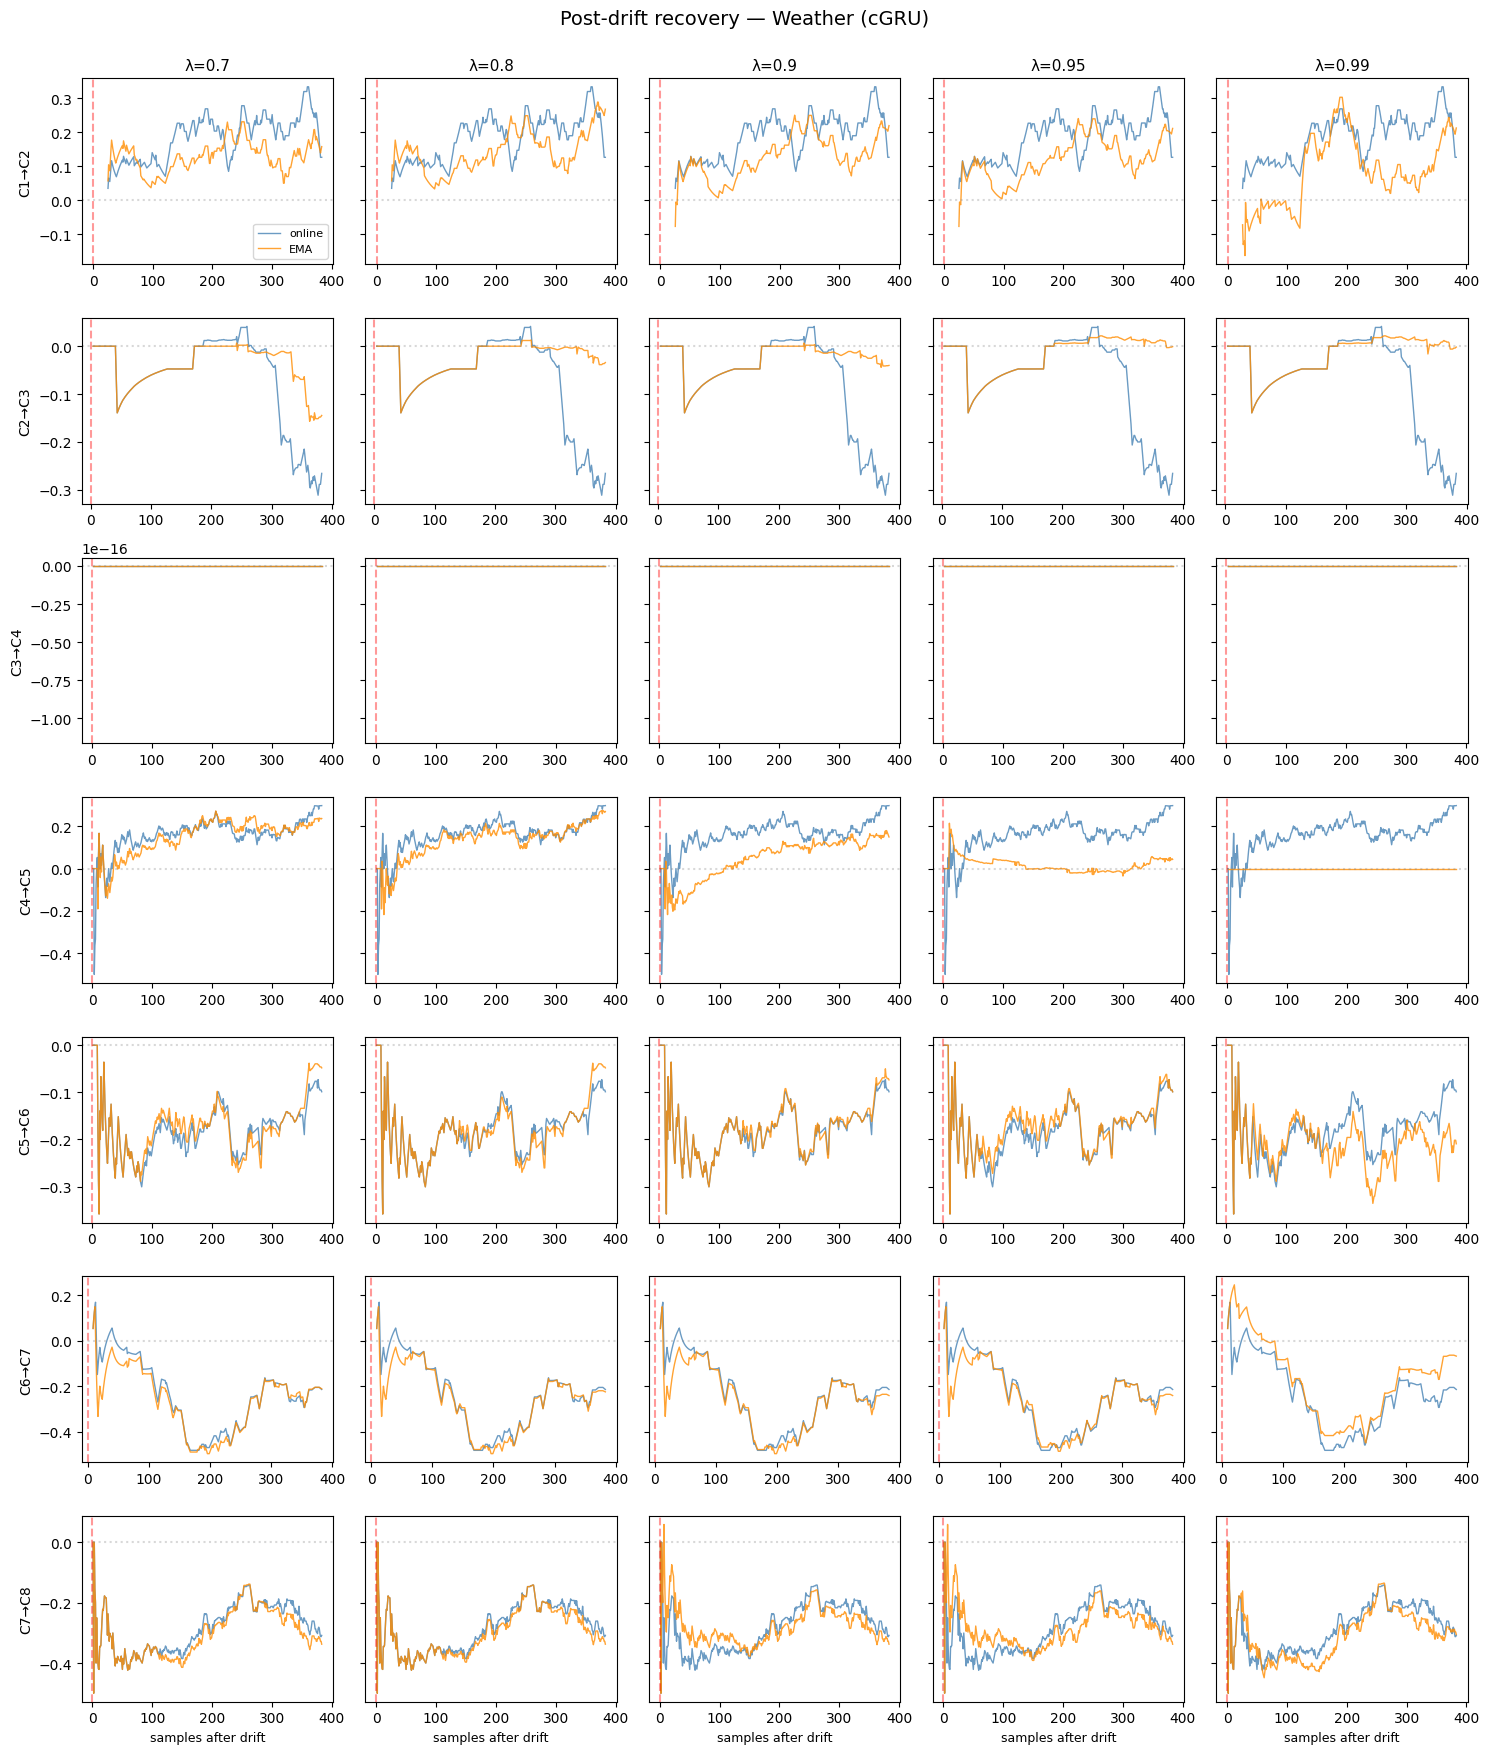

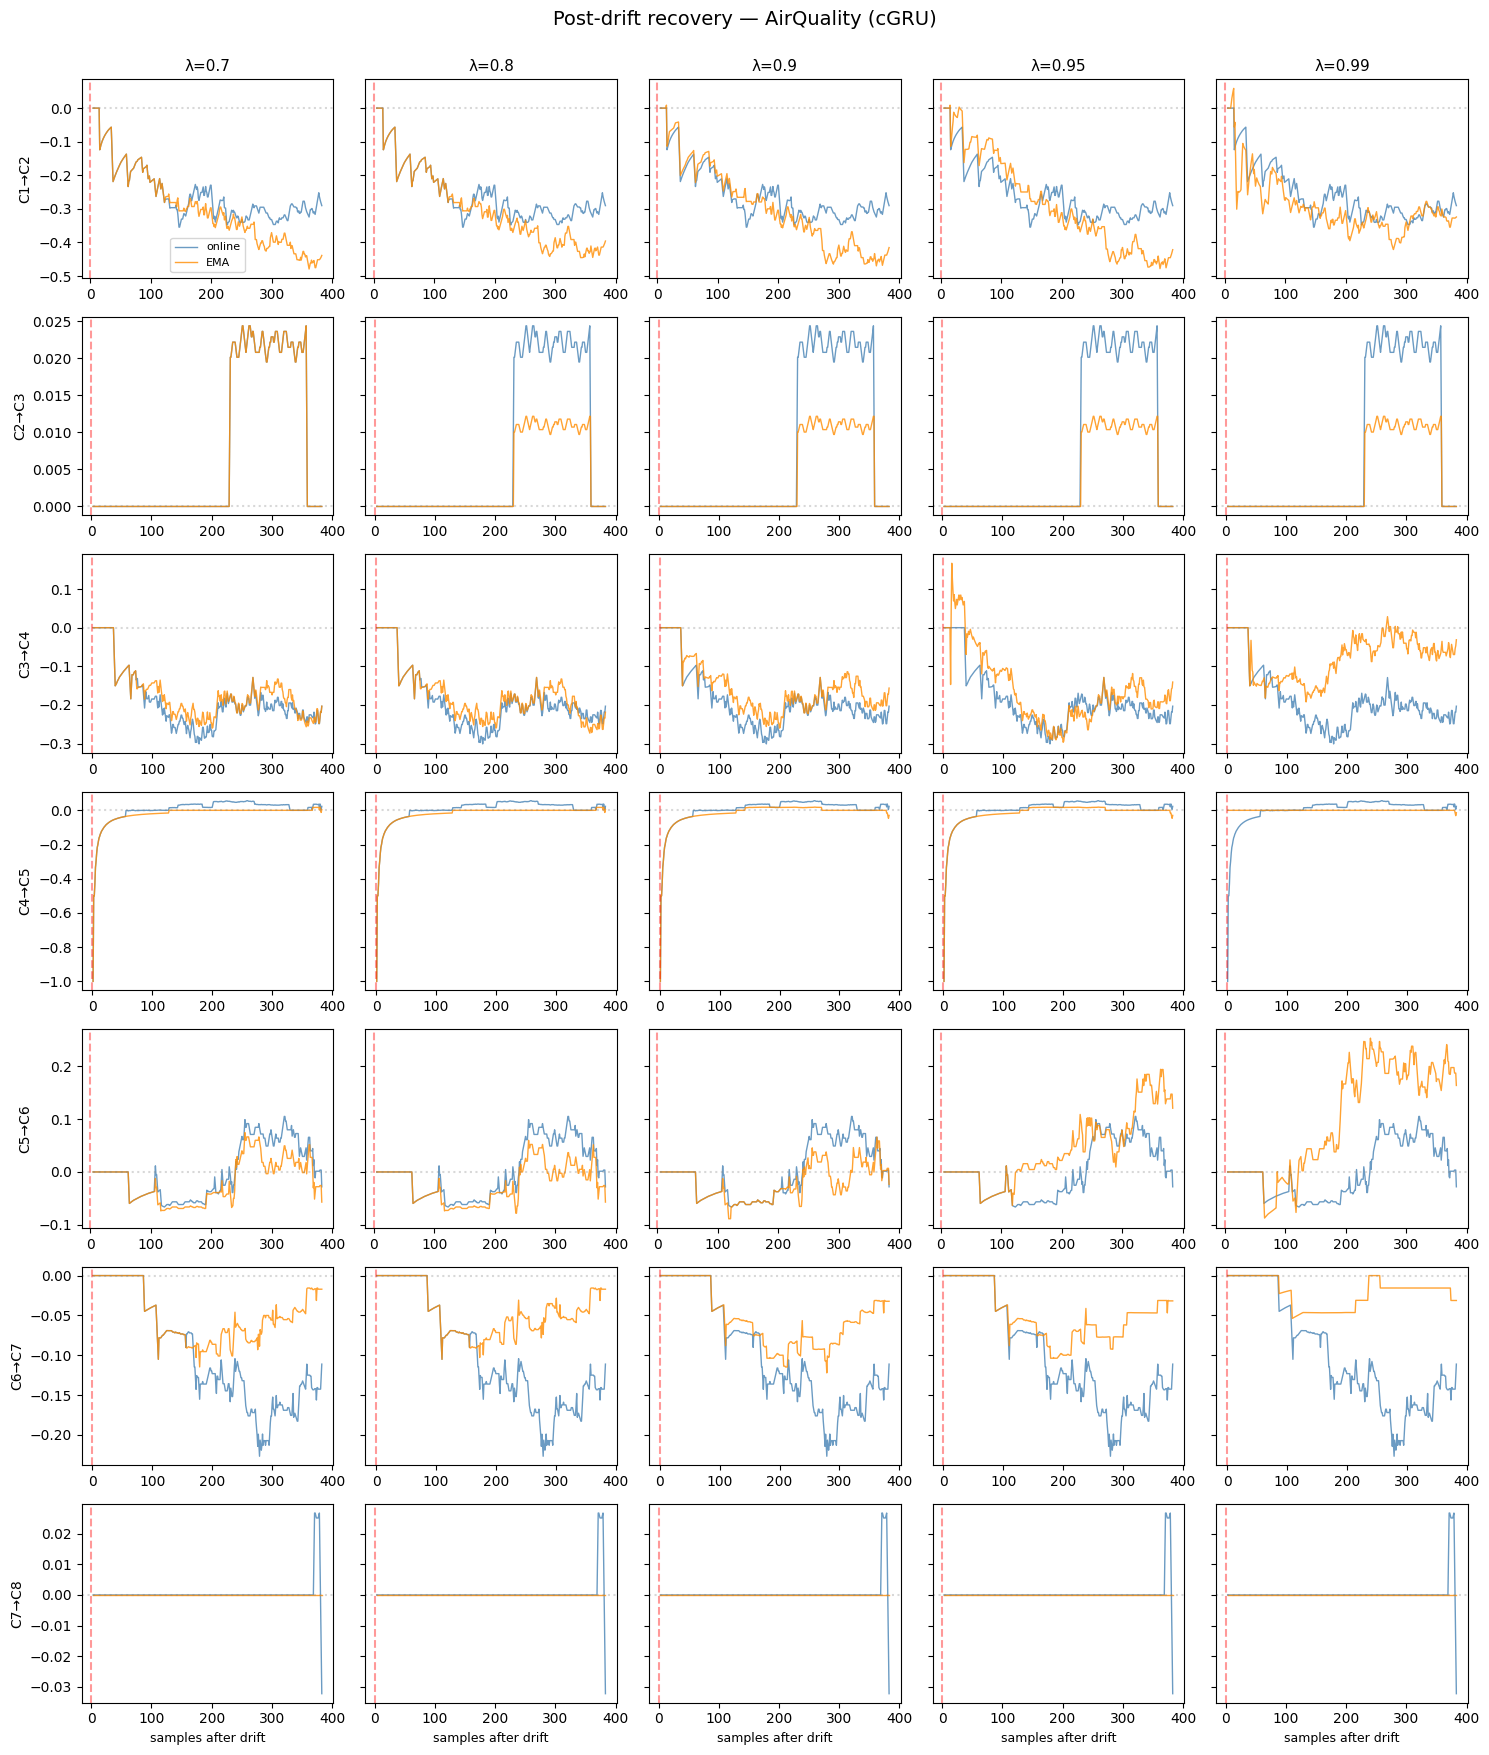

In [50]:
plot_lambda_comparison_per_drift(all_results, 'Weather',    np.array(all_w_cGRU_tasks),  SLOPE_WINDOW)
plot_lambda_comparison_per_drift(all_results, 'AirQuality', np.array(all_aq_cGRU_tasks), SLOPE_WINDOW)

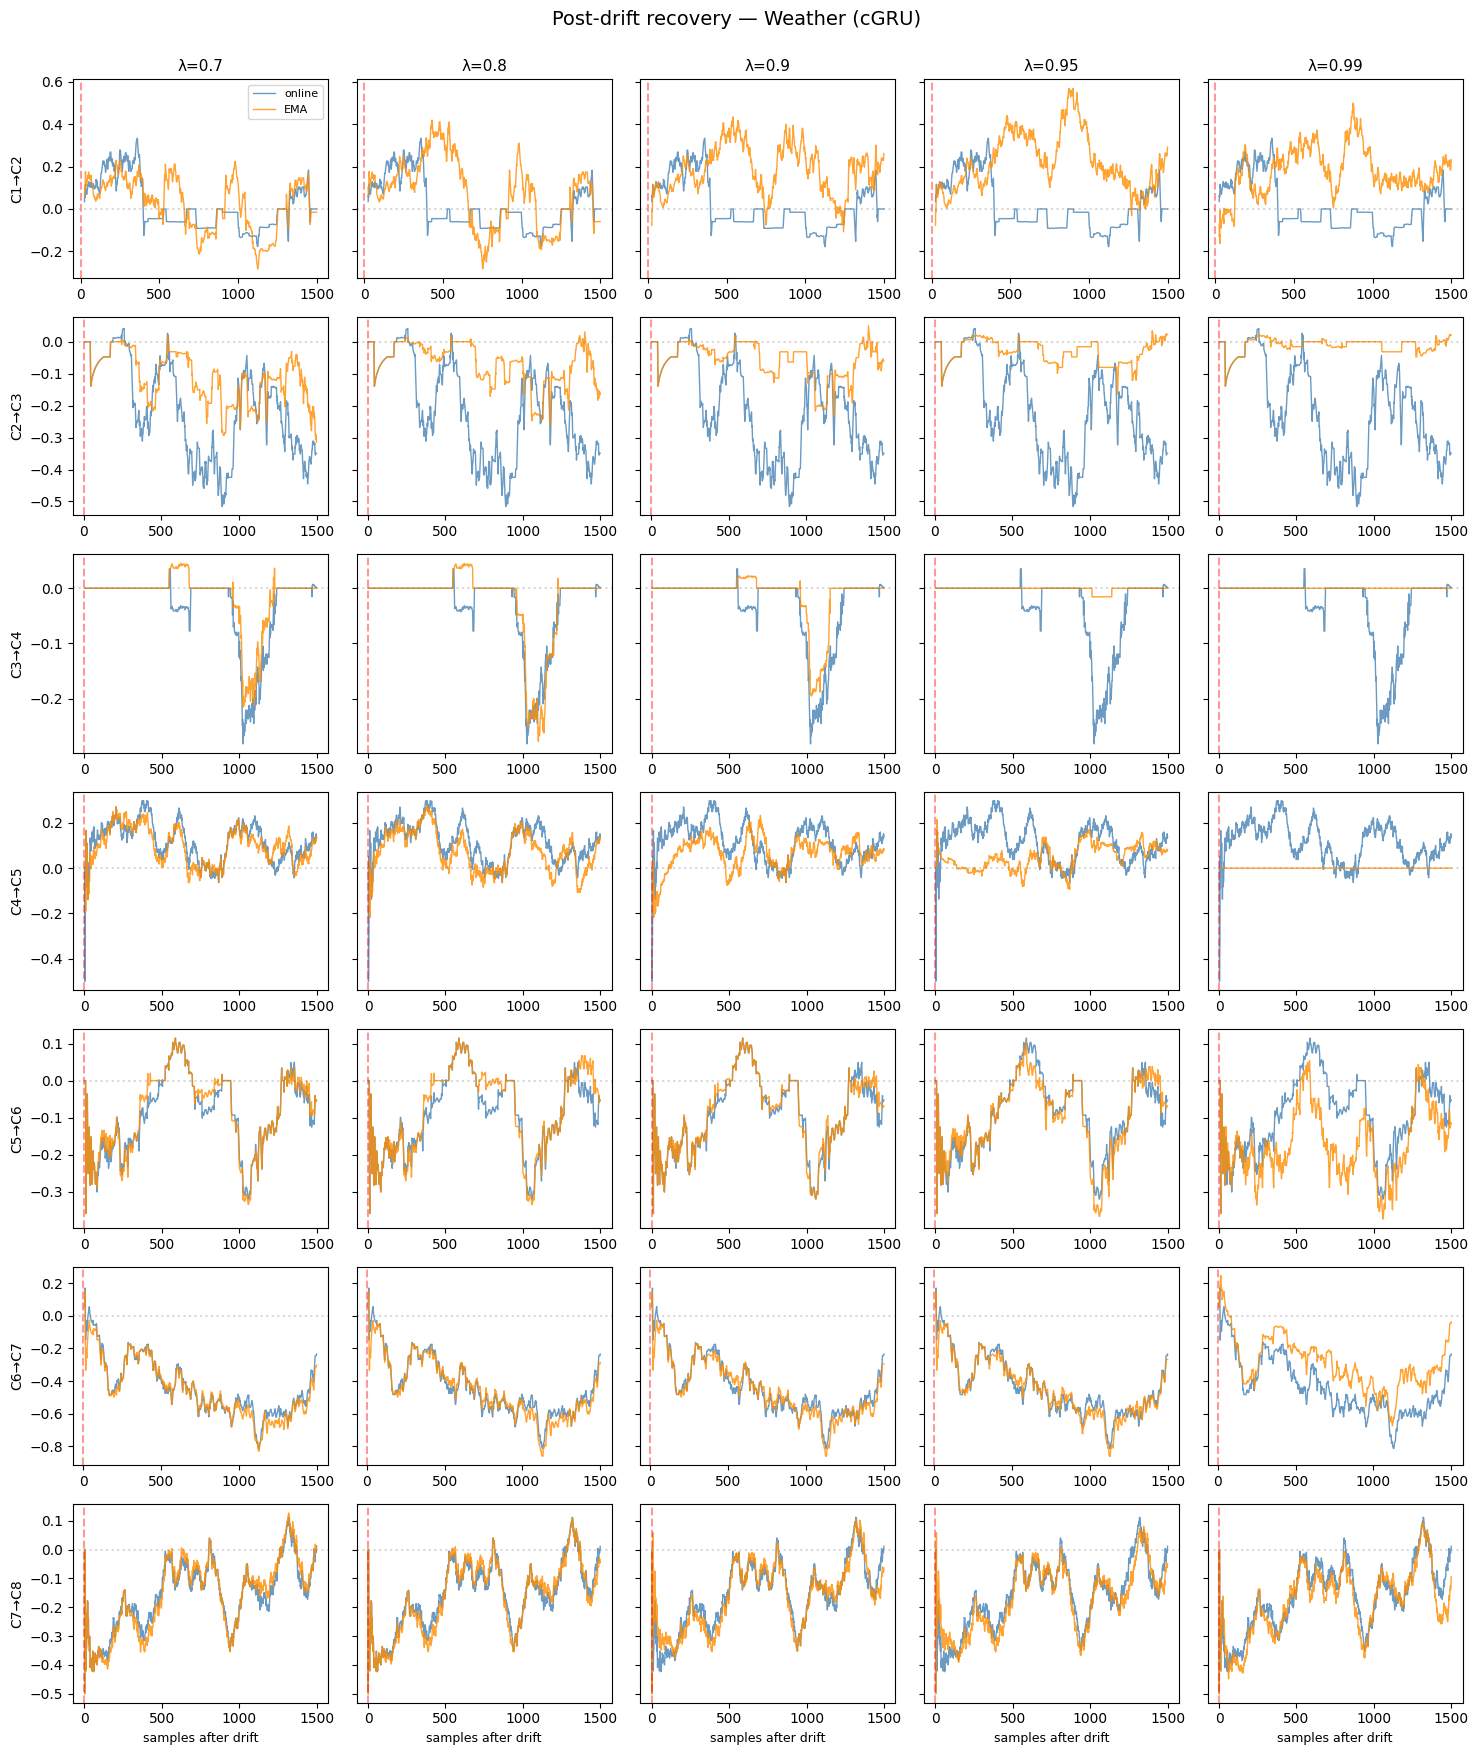

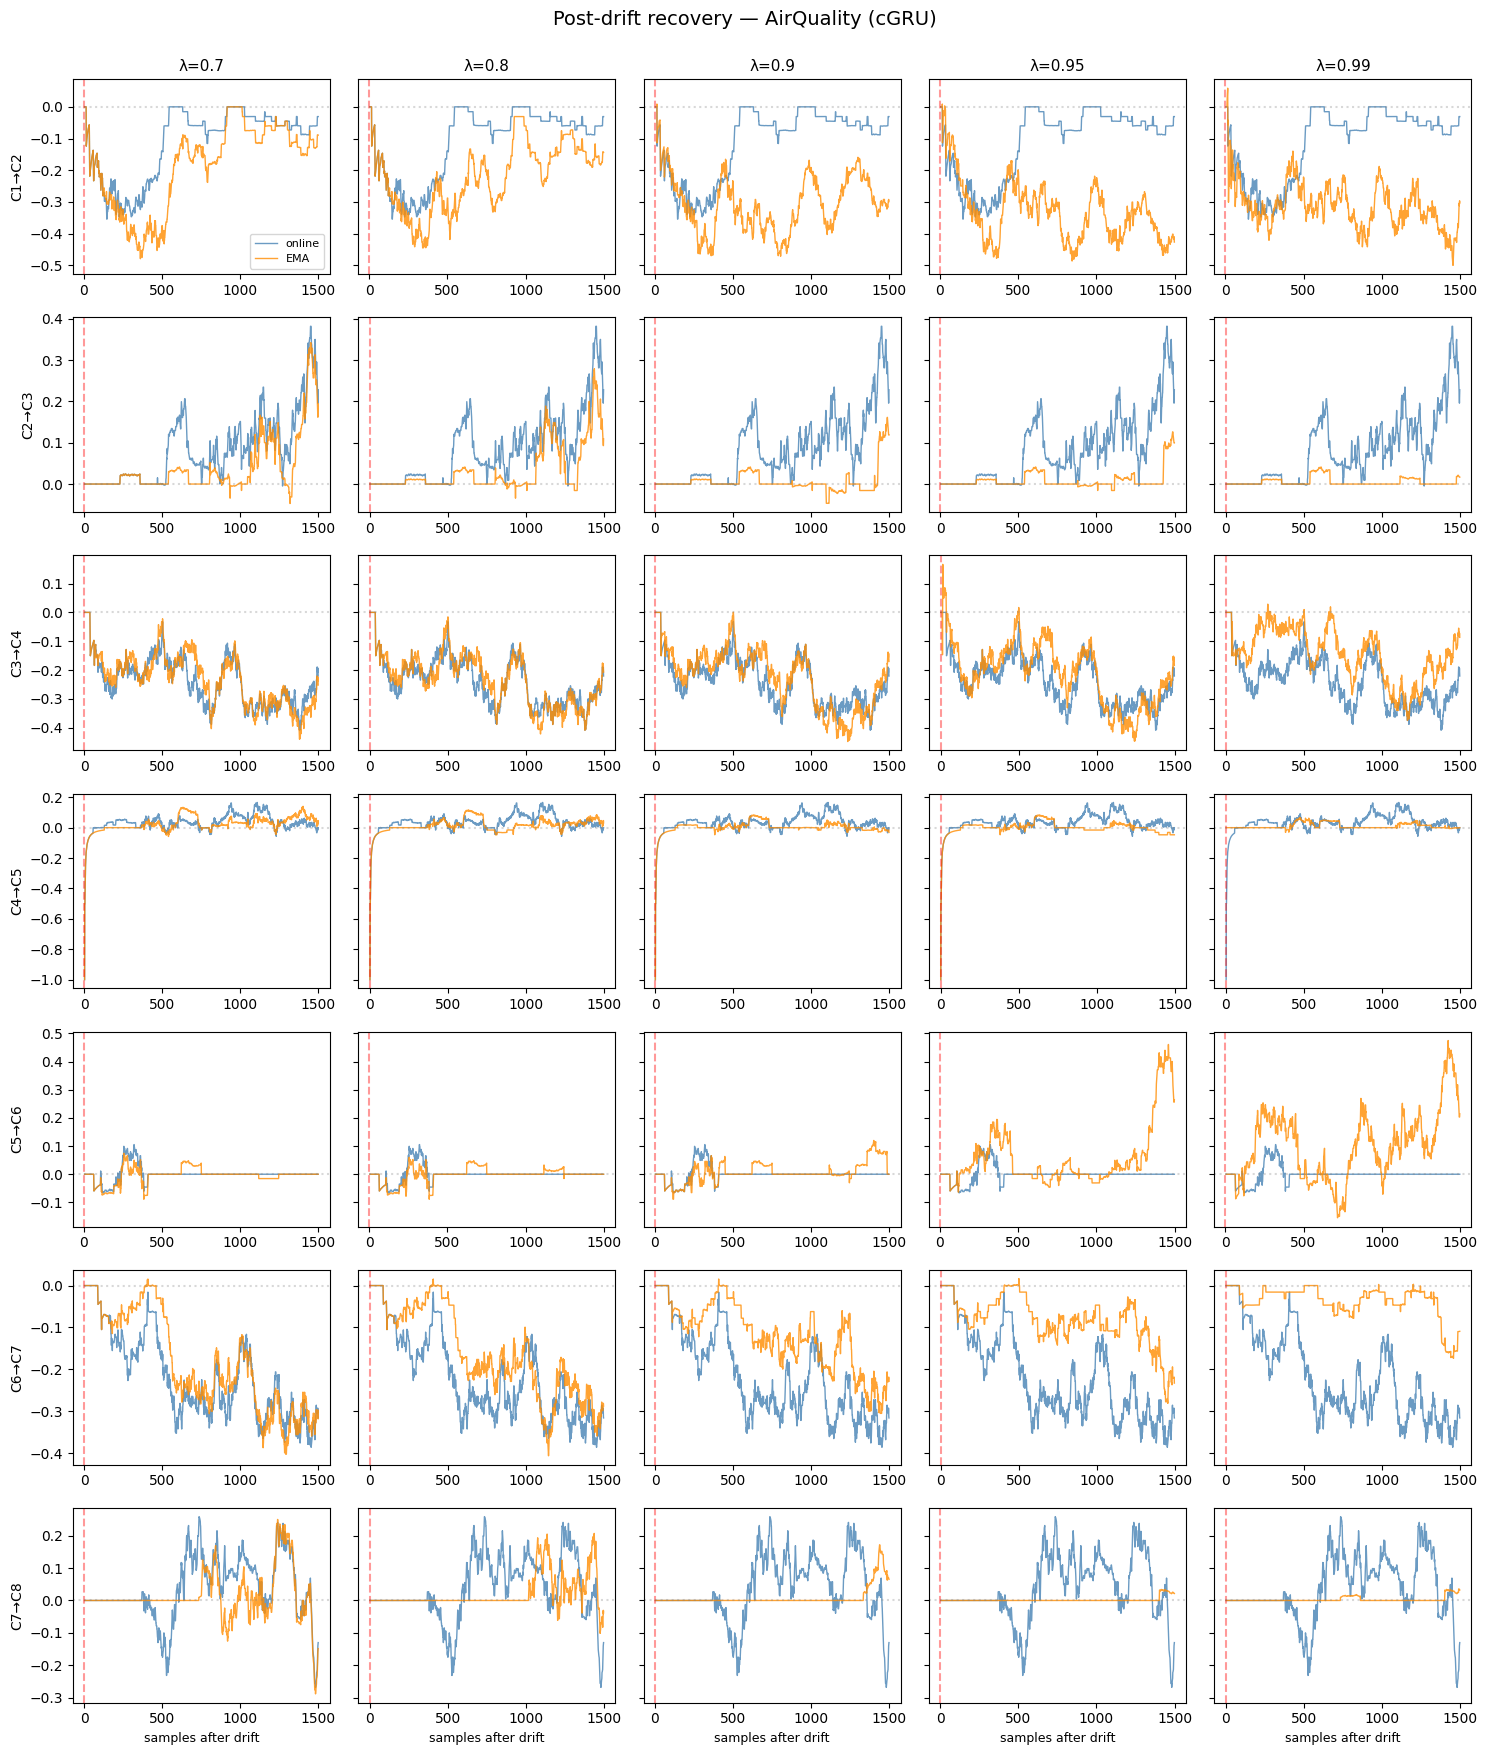

In [48]:
#Window set to 1500 to better compare the slopes and the recovery curves side to side
plot_lambda_comparison_per_drift(all_results, 'Weather',    np.array(all_w_cGRU_tasks),  1500)
plot_lambda_comparison_per_drift(all_results, 'AirQuality', np.array(all_aq_cGRU_tasks), 1500)

## **SAVE RESULTS FOR DATASET AND MODEL COMPARISON**
The kappa arrays, task IDs, and configuration parameters are saved to cGRU_results.npz. The companion analysis notebook (Models_Analysis.ipynb) loads this file together with cLSTM_results.npz to perform the cross-architecture comparison.

In [49]:
np.savez('../results/cGRU_results.npz',
    # Lambda sweep — kappa curves
    k_w_L07_online=k_w_cGRU_online, k_w_L07_ema=k_w_cGRU_ema,
    k_w_L08_online=k_w_cGRU_online_tune, k_w_L08_ema=k_w_cGRU_ema_tune,
    k_w_L09_online=k_w_cGRU_online_tune2, k_w_L09_ema=k_w_cGRU_ema_tune2,
    k_w_L095_online=k_w_cGRU_online_tune3, k_w_L095_ema=k_w_cGRU_ema_tune3,
    k_w_L099_online=k_w_cGRU_online_tune4, k_w_L099_ema=k_w_cGRU_ema_tune4,
    # Same for AirQuality
    k_aq_L07_online=k_aq_cGRU_online, k_aq_L07_ema=k_aq_cGRU_ema,
    k_aq_L08_online=k_aq_cGRU_online_tune,  k_aq_L08_ema=k_aq_cGRU_ema_tune,
    k_aq_L09_online=k_aq_cGRU_online_tune2, k_aq_L09_ema=k_aq_cGRU_ema_tune2,
    k_aq_L095_online=k_aq_cGRU_online_tune3, k_aq_L095_ema=k_aq_cGRU_ema_tune3,
    k_aq_L099_online=k_aq_cGRU_online_tune4, k_aq_L099_ema=k_aq_cGRU_ema_tune4,
    # Tasks (same across lambdas since data is fixed, but save for safety)
    tasks_w=np.array(all_w_cGRU_tasks),
    tasks_aq=np.array(all_aq_cGRU_tasks),
    # Configuration metadata
    SLOPE_WINDOW=SLOPE_WINDOW,
    K_ROLLING_WINDOW=K_ROLLING_WINDOW,
    ZOOM_WINDOW=ZOOM_WINDOW, 
)